# Project VGG

## Download and Store the Open Images

We download images from the ["Apple", "Banana", "Lemon"] classes.

In [ ]:
!pip install fiftyone datasets torch torchvision

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.7/17.7 MB 95.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.8/43.8 kB 5.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 140.6/140.6 kB 16.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 112.8/112.8 kB 11.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 4.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.6/61.6 kB 7.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 112.5/112.5 kB 13.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 74.8/74.8 kB 9.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.9/9.9 MB 123.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 101.6/101.6 kB 13.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 105.4 MB/s eta 0:

In [ ]:
import fiftyone as fo
import pandas as pd
from fiftyone import ViewField as F
from pathlib import Path


/usr/local/lib/python3.12/dist-packages/glob2/fnmatch.py:141: SyntaxWarning: invalid escape sequence '\Z'
  return '(?ms)' + res + '\Z'


**Set random seed for reproducibility**

In [ ]:
import os
import random
import numpy as np
import torch

seed = 42

def seed_everything(seed=42):
    os.environ["PYTHONHASHSEED"] = str(seed)

    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)

    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    torch.use_deterministic_algorithms(True, warn_only=True)

seed_everything(seed)
print(f"Random seed set to {seed}")

Random seed set to 42


In [ ]:
my_classes = ["Apple", "Banana", "Lemon"]
export_dir = "./project-vgg"


In [ ]:
if not Path(export_dir).exists():
    Path(export_dir).mkdir(parents=True, exist_ok=True)
    dataset = fo.zoo.load_zoo_dataset(
        "open-images-v7",
        split="train",
        label_types=["detections"],
        classes=my_classes,
        shuffle=True,
        seed=seed
    )

    dataset = dataset.filter_labels("ground_truth", F("label").is_in(my_classes))

    patches = dataset.to_patches("ground_truth")

    patches.export(
        export_dir=export_dir,
        dataset_type=fo.types.ImageClassificationDirectoryTree,
        label_field="ground_truth",
    )

INFO:fiftyone.zoo.datasets:Downloading split 'train' to '/root/fiftyone/open-images-v7/train' if necessary


INFO:fiftyone.utils.openimages:Downloading 'https://storage.googleapis.com/openimages/2018_04/train/train-images-boxable-with-rotation.csv' to '/root/fiftyone/open-images-v7/train/metadata/image_ids.csv'


 100% |██████|    4.8Gb/4.8Gb [38.5s elapsed, 0s remaining, 117.4Mb/s]      


INFO:eta.core.utils: 100% |██████|    4.8Gb/4.8Gb [38.5s elapsed, 0s remaining, 117.4Mb/s]      


INFO:fiftyone.utils.openimages:Downloading 'https://storage.googleapis.com/openimages/v5/class-descriptions-boxable.csv' to '/root/fiftyone/open-images-v7/train/metadata/classes.csv'


...

Directory './project-vgg' already exists; export will be merged with existing files


Detected an image classification exporter and a label field 'ground_truth' of type <class 'fiftyone.core.labels.Detection'>. Exporting image patches...


INFO:fiftyone.utils.data.exporters:Detected an image classification exporter and a label field 'ground_truth' of type <class 'fiftyone.core.labels.Detection'>. Exporting image patches...


 100% |███████████████| 7266/7266 [1.5m elapsed, 0s remaining, 107.8 samples/s]      


INFO:eta.core.utils: 100% |███████████████| 7266/7266 [1.5m elapsed, 0s remaining, 107.8 samples/s]      


## Load the images as Huggingface dataset

In [ ]:
from datasets import load_dataset

In [ ]:
# Load images where each subfolder is treated as a class label
hf_dataset = load_dataset("imagefolder", data_dir=export_dir)

# Class names inferred from subdirectory names
class_names = hf_dataset["train"].features["label"].names
print("Classes:", class_names)

hf_dataset

Resolving data files:   0%|          | 0/7266 [00:00<?, ?it/s]

Generating train split: 0 examples [00:00, ? examples/s]

Classes: ['Apple', 'Banana', 'Lemon']


DatasetDict({
    train: Dataset({
        features: ['image', 'label'],
        num_rows: 7266
    })
})

## Analyse the Dataset

**Explore the dataset**
- What classes?
- Distribution of images?
- Any imbalances?
- What did you notice about the images that could affect the model training and performance?

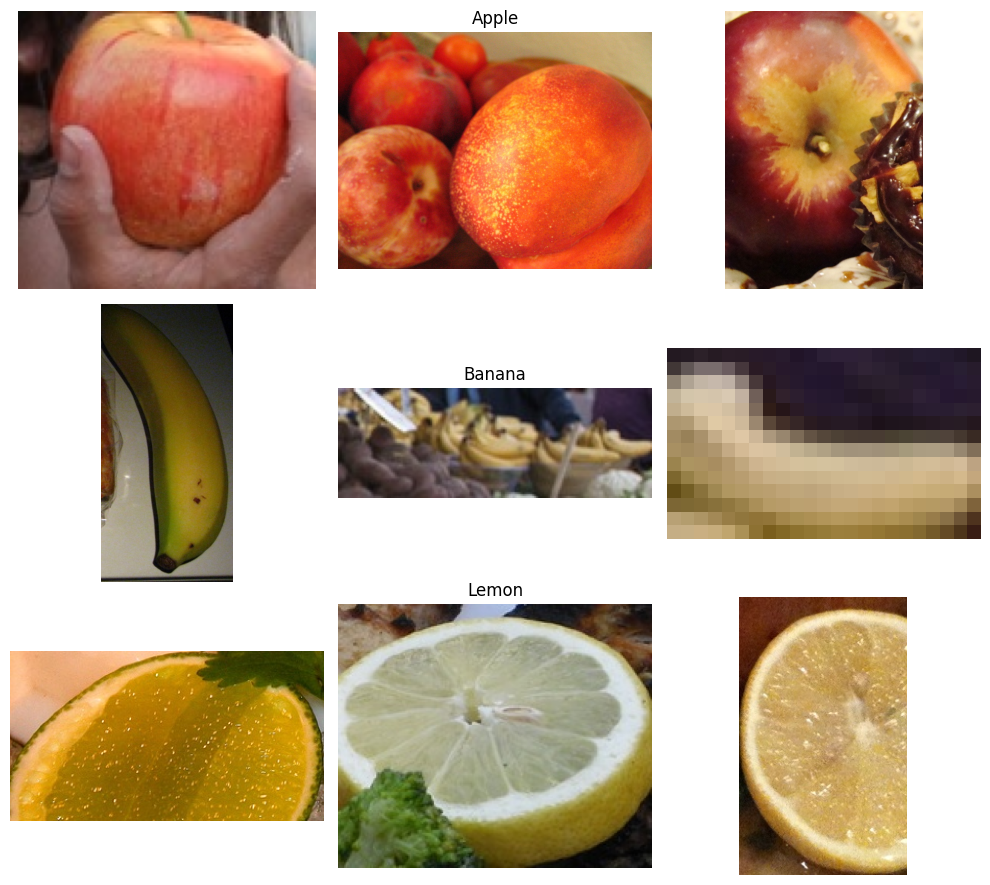

In [ ]:
import matplotlib.pyplot as plt

# Get class names
class_names = hf_dataset["train"].features["label"].names

# Store images per class
images_per_class = {name: [] for name in class_names}

# Collect 3 images per class
for sample in hf_dataset["train"]:
    label_name = class_names[sample["label"]]

    if len(images_per_class[label_name]) < 3:
        images_per_class[label_name].append(sample["image"])

    # Stop once we have 3 for each class
    if all(len(v) == 3 for v in images_per_class.values()):
        break

# Plot
fig, axes = plt.subplots(len(class_names), 3, figsize=(10, 9))

for i, class_name in enumerate(class_names):
    for j in range(3):
        axes[i, j].imshow(images_per_class[class_name][j])
        axes[i, j].axis("off")
        if j == 1:
            axes[i, j].set_title(class_name, fontsize=12)

plt.tight_layout()
plt.show()

In [ ]:
# Explore class distribution
train_ds = hf_dataset["train"]
n_images = len(train_ds)

label_counts = pd.Series(train_ds["label"]).value_counts().sort_index()
dist_df = pd.DataFrame(
    {
        "class_id": label_counts.index,
        "class_name": [class_names[i] for i in label_counts.index],
        "images": label_counts.values,
    }
).sort_values("images", ascending=False).reset_index(drop=True)

dist_df["share_%"] = (dist_df["images"] / n_images * 100).round(2)

print(f"Total images: {n_images}")
print("\nClass distribution:")
display(dist_df)

if dist_df["images"].min() > 0:
    imbalance_ratio = dist_df["images"].max() / dist_df["images"].min()
    print(f"\nImbalance ratio (max/min): {imbalance_ratio:.2f}")
else:
    print("\nAt least one class has 0 images.")

# Explore image properties that may affect training
img_rows = []
for sample in train_ds:
    img = sample["image"]   # PIL image
    w, h = img.size
    img_rows.append(
        {
            "label_id": sample["label"],
            "class_name": class_names[sample["label"]],
            "width": w,
            "height": h,
            "aspect_ratio": w / h if h else None,
            "mode": img.mode,
            "min_side": min(w, h),
        }
    )

img_df = pd.DataFrame(img_rows)

print("\nImage size summary:")
display(img_df[["width", "height", "aspect_ratio"]].describe().round(2))

print("\nColor mode distribution:")
display(img_df["mode"].value_counts().rename_axis("mode").reset_index(name="count"))

print("\nTop 10 most common resolutions:")
display(
    img_df.groupby(["width", "height"])
    .size()
    .reset_index(name="count")
    .sort_values("count", ascending=False)
    .head(10)
)

small_share = (img_df["min_side"] < 128).mean() * 100
extreme_ar_share = ((img_df["aspect_ratio"] > 2.0) | (img_df["aspect_ratio"] < 0.5)).mean() * 100

print("\nPotential training-impact observations:")
print(f"- Very small images (min side < 128 px): {small_share:.2f}%")
print(f"- Extreme aspect ratios (<0.5 or >2.0): {extreme_ar_share:.2f}%")

if imbalance_ratio > 1.5:
    print("- Noticeable class imbalance: might need class weighting, resampling, or augmentation.")
else:
    print("- Class balance looks fairly reasonable.")

if img_df["mode"].nunique() > 1:
    print("- Mixed image modes detected (e.g., RGB/RGBA/L): standardize preprocessing to a single mode (usually RGB).")

if small_share > 20:
    print("- Many small images may reduce feature quality; careful resizing/augmentation is important.")

if extreme_ar_share > 15:
    print("- Many extreme aspect ratios: use robust resize/crop strategy to avoid distortion.")

Total images: 7266

Class distribution:


,class_id,class_name,images,share_%
0,0,Apple,3898,53.65
1,2,Lemon,1756,24.17
2,1,Banana,1612,22.19



Imbalance ratio (max/min): 2.42

Image size summary:


,width,height,aspect_ratio
count,7266.00,7266.00,7266.00
mean,247.60,220.85,1.23
std,238.44,200.83,0.78
min,3.00,5.00,0.12
25%,83.00,77.25,0.89
50%,166.00,156.00,1.05
75%,319.00,299.00,1.33
max,1024.00,1023.00,17.77



Color mode distribution:


,mode,count
0,RGB,7243
1,L,23



Top 10 most common resolutions:


,width,height,count
6577,1023,767,18
6230,767,1023,9
6565,1023,682,8
6519,1022,1022,8
6574,1023,764,6
6516,1022,767,6
365,32,32,5
126,18,19,5
258,26,25,4
167,21,19,4



Potential training-impact observations:
- Very small images (min side < 128 px): 46.44%
- Extreme aspect ratios (<0.5 or >2.0): 14.12%
- Noticeable class imbalance: might need class weighting, resampling, or augmentation.
- Mixed image modes detected (e.g., RGB/RGBA/L): standardize preprocessing to a single mode (usually RGB).
- Many small images may reduce feature quality; careful resizing/augmentation is important.


## Split the Dataset

Preparation: Split dataset into a 75/25 Train/test split

In [ ]:
# 75/25 train-test split (stratified by class label)
hf_dataset = hf_dataset["train"].train_test_split(
    test_size=0.25,
    seed=42,
    stratify_by_column="label",
)

train_ds = hf_dataset["train"]
test_ds = hf_dataset["test"]

print(f"Train samples: {len(train_ds)} ({len(train_ds)/n_images:.2%})")
print(f"Test samples:  {len(test_ds)} ({len(test_ds)/n_images:.2%})")

Train samples: 5449 (74.99%)
Test samples:  1817 (25.01%)


## Train VGG16 from scratch

Train a VGG 16 network from scratch (randomly initialized weights) and estimate the testset accuracy.

In [ ]:
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models

import torch.nn as nn

In [ ]:
# The architecture configuration for VGG16
# Improved VGG initialization: He/Kaiming for conv layers, Xavier for linear layers
# Numbers represent the number of output channels in a Conv2d layer
# 'M' represents a MaxPool2d layer
VGG16_CONFIG = [64, 64, 'M', 128, 128, 'M', 256, 256, 256, 'M', 512, 512, 512, 'M', 512, 512, 512, 'M']

class VGG16(nn.Module):
    def __init__(self, weights=None, in_channels=3, num_classes=1000):
        super().__init__()
        self.in_channels = in_channels

        self.features = self.create_conv_layers(VGG16_CONFIG)
        self.avgpool = nn.AdaptiveAvgPool2d((7, 7))
        self.classifier = nn.Sequential(
            nn.Linear(512 * 7 * 7, 4096),
            nn.ReLU(inplace=True),
            nn.Dropout(p=0.5),
            nn.Linear(4096, 4096),
            nn.ReLU(inplace=True),
            nn.Dropout(p=0.5),
            nn.Linear(4096, num_classes),
        )

        if weights is None:
            self._initialize_weights()
        else:
            self.load_state_dict(weights)

    def forward(self, x):
        x = self.features(x)
        x = self.avgpool(x)
        x = torch.flatten(x, 1)
        x = self.classifier(x)
        return x

    def create_conv_layers(self, architecture):
        layers = []
        in_channels = self.in_channels

        for x in architecture:
            if isinstance(x, int):
                layers.extend([
                    nn.Conv2d(in_channels, x, kernel_size=3, stride=1, padding=1),
                    nn.ReLU(inplace=True),
                ])
                in_channels = x
            elif x == "M":
                layers.append(nn.MaxPool2d(kernel_size=2, stride=2))

        return nn.Sequential(*layers)

    def _initialize_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight, mode="fan_out", nonlinearity="relu")
                if m.bias is not None:
                    nn.init.zeros_(m.bias)
            elif isinstance(m, nn.Linear):
                nn.init.xavier_uniform_(m.weight)
                nn.init.zeros_(m.bias)


In [ ]:
%%time

# Reuse existing train_ds, test_ds, class_names from previous cells
num_classes = len(class_names)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

train_tfms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

test_tfms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

class HFDatasetWrapper(Dataset):
    def __init__(self, hf_split, transform=None):
        self.ds = hf_split
        self.transform = transform

    def __len__(self):
        return len(self.ds)

    def __getitem__(self, idx):
        sample = self.ds[idx]
        image = sample["image"].convert("RGB")
        label = sample["label"]
        if self.transform is not None:
            image = self.transform(image)
        return image, label

train_torch_ds = HFDatasetWrapper(train_ds, transform=train_tfms)
test_torch_ds = HFDatasetWrapper(test_ds, transform=test_tfms)

train_loader = DataLoader(train_torch_ds, batch_size=16, shuffle=True, num_workers=2, pin_memory=True)
test_loader = DataLoader(test_torch_ds, batch_size=32, shuffle=False, num_workers=2, pin_memory=True)

# VGG16 from scratch (randomly initialized)
# model = models.vgg16(weights=None)
model = VGG16(weights=None)
model.classifier[6] = nn.Linear(model.classifier[6].in_features, num_classes)
model = model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

epochs = 10
for epoch in range(epochs):
    model.train()
    running_loss, correct, total = 0.0, 0, 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        logits = model(images)
        loss = criterion(logits, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        preds = logits.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    train_loss = running_loss / total
    train_acc = correct / total
    print(f"Epoch {epoch+1}/{epochs} | train_loss={train_loss:.4f} | train_acc={train_acc:.4f}")

# Test accuracy
model.eval()
correct, total = 0, 0
with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        logits = model(images)
        preds = logits.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

test_acc = correct / total
print(f"Estimated test accuracy: {test_acc:.4f} ({100*test_acc:.2f}%)")

/usr/local/lib/python3.12/dist-packages/torch/autograd/graph.py:865: UserWarning: adaptive_avg_pool2d_backward_cuda does not have a deterministic implementation, but you set 'torch.use_deterministic_algorithms(True, warn_only=True)'. You can file an issue at https://github.com/pytorch/pytorch/issues to help us prioritize adding deterministic support for this operation. (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:160.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


Epoch 1/10 | train_loss=0.8009 | train_acc=0.6128
Epoch 2/10 | train_loss=0.7420 | train_acc=0.6500
Epoch 3/10 | train_loss=0.6939 | train_acc=0.6876
Epoch 4/10 | train_loss=0.6329 | train_acc=0.7260
Epoch 5/10 | train_loss=0.6056 | train_acc=0.7590
Epoch 6/10 | train_loss=0.5666 | train_acc=0.7682
Epoch 7/10 | train_loss=0.5400 | train_acc=0.7809
Epoch 8/10 | train_loss=0.5107 | train_acc=0.7915
Epoch 9/10 | train_loss=0.4940 | train_acc=0.8040
Epoch 10/10 | train_loss=0.4569 | train_acc=0.8148
Estimated test accuracy: 0.7854 (78.54%)
CPU times: user 15min 21s, sys: 12.6 s, total: 15min 34s
Wall time: 16min 46s


## Transfer Learning

Experiment transfer learning: Use an imagenet pretrained VGG 16 architecture, train the model and estimate the testset accuracy. Show the differences in loss and accuracy of the plain and pre-trained network over the first 10 epochs.

In [ ]:
%%time

# Compare plain VGG16 (random init) vs ImageNet-pretrained VGG16 over 10 epochs

torch.manual_seed(42)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(42)

def evaluate(model, loader, loss_fn, device):
    model.eval()
    total_loss, correct_preds, total_samples = 0.0, 0, 0

    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            out = model(x)
            loss = loss_fn(out, y)

            total_loss += loss.item() * x.size(0)
            pred = out.argmax(dim=1)
            correct_preds += (pred == y).sum().item()
            total_samples += y.size(0)

    return total_loss / total_samples, correct_preds / total_samples

def train_and_track(model, train_loader, test_loader, loss_fn, device, epochs=10, lr=1e-4):
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    history = []

    for ep in range(1, epochs + 1):
        model.train()
        running_loss, running_correct, running_total = 0.0, 0, 0

        for x, y in train_loader:
            x, y = x.to(device), y.to(device)

            optimizer.zero_grad()
            out = model(x)
            loss = loss_fn(out, y)
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * x.size(0)
            pred = out.argmax(dim=1)
            running_correct += (pred == y).sum().item()
            running_total += y.size(0)

        train_loss_ep = running_loss / running_total
        train_acc_ep = running_correct / running_total
        test_loss_ep, test_acc_ep = evaluate(model, test_loader, loss_fn, device)

        history.append(
            {
                "epoch": ep,
                "train_loss": train_loss_ep,
                "train_acc": train_acc_ep,
                "test_loss": test_loss_ep,
                "test_acc": test_acc_ep,
            }
        )

    return pd.DataFrame(history)

# 1) Plain VGG16 (from scratch)
# plain_model = models.vgg16(weights=None)
plain_model = models.vgg16(weights=None)
plain_model.classifier[6] = nn.Linear(plain_model.classifier[6].in_features, num_classes)
plain_model = plain_model.to(device)

plain_hist = train_and_track(
    model=plain_model,
    train_loader=train_loader,
    test_loader=test_loader,
    loss_fn=criterion,
    device=device,
    epochs=10,
    lr=1e-4,
)

# 2) Pretrained VGG16 (ImageNet)
pretrained_model = models.vgg16(weights=models.VGG16_Weights.IMAGENET1K_V1)
pretrained_model.classifier[6] = nn.Linear(pretrained_model.classifier[6].in_features, num_classes)
pretrained_model = pretrained_model.to(device)

pre_hist = train_and_track(
    model=pretrained_model,
    train_loader=train_loader,
    test_loader=test_loader,
    loss_fn=criterion,
    device=device,
    epochs=10,
    lr=1e-5,  # smaller LR is usually better for fine-tuning
)

# Build comparison table
comparison = plain_hist.merge(pre_hist, on="epoch", suffixes=("_plain", "_pretrained"))
comparison["delta_train_loss_pre_minus_plain"] = comparison["train_loss_pretrained"] - comparison["train_loss_plain"]
comparison["delta_test_loss_pre_minus_plain"] = comparison["test_loss_pretrained"] - comparison["test_loss_plain"]
comparison["delta_train_acc_pre_minus_plain"] = comparison["train_acc_pretrained"] - comparison["train_acc_plain"]
comparison["delta_test_acc_pre_minus_plain"] = comparison["test_acc_pretrained"] - comparison["test_acc_plain"]

print("Final test accuracy (plain):      {:.4f}".format(plain_hist.iloc[-1]["test_acc"]))
print("Final test accuracy (pretrained): {:.4f}".format(pre_hist.iloc[-1]["test_acc"]))
display(comparison.round(4))

# Optional quick plots
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(comparison["epoch"], comparison["train_loss_plain"], label="Plain train loss")
axes[0].plot(comparison["epoch"], comparison["test_loss_plain"], "--", label="Plain test loss")
axes[0].plot(comparison["epoch"], comparison["train_loss_pretrained"], label="Pretrained train loss")
axes[0].plot(comparison["epoch"], comparison["test_loss_pretrained"], "--", label="Pretrained test loss")
axes[0].set_title("Loss over first 10 epochs")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].legend()

axes[1].plot(comparison["epoch"], comparison["train_acc_plain"], label="Plain train acc")
axes[1].plot(comparison["epoch"], comparison["test_acc_plain"], "--", label="Plain test acc")
axes[1].plot(comparison["epoch"], comparison["train_acc_pretrained"], label="Pretrained train acc")
axes[1].plot(comparison["epoch"], comparison["test_acc_pretrained"], "--", label="Pretrained test acc")
axes[1].set_title("Accuracy over first 10 epochs")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].legend()

plt.tight_layout()
plt.show()

Downloading: "https://download.pytorch.org/models/vgg16-397923af.pth" to /root/.cache/torch/hub/checkpoints/vgg16-397923af.pth


URLError: <urlopen error [Errno 104] Connection reset by peer>

## Data Augmentation

Experiment data augmentation: Add data augmentation and train again, discuss results
- Random rotate
- Random translate
- Random crop

### Train the plain VGG with data augmentation

,epoch,train_loss_plain,train_acc_plain,test_loss_plain,test_acc_plain,train_loss_aug,train_acc_aug,test_loss_aug,test_acc_aug,delta_test_acc_aug_minus_plain,delta_test_loss_aug_minus_plain
0,1,0.8015,0.6098,0.7592,0.6313,0.8169,0.5974,0.7476,0.6346,0.0033,-0.0115
1,2,0.7323,0.6508,0.7540,0.6401,0.7472,0.6401,0.7309,0.6159,-0.0242,-0.0231
2,3,0.6956,0.6726,0.7231,0.6912,0.7219,0.6544,0.7146,0.6786,-0.0127,-0.0086
3,4,0.6671,0.7089,0.6359,0.7061,0.7174,0.6665,0.6868,0.6802,-0.0259,0.0509
4,5,0.6247,0.7335,0.5818,0.7672,0.6983,0.6719,0.6730,0.6973,-0.0699,0.0912
5,6,0.5748,0.7631,0.5753,0.7666,0.6932,0.6832,0.6484,0.7078,-0.0589,0.0732
6,7,0.5545,0.7768,0.5681,0.7738,0.6581,0.7194,0.6383,0.7386,-0.0352,0.0702
7,8,0.5192,0.7886,0.5397,0.7942,0.6273,0.7379,0.6133,0.7595,-0.0347,0.0736
8,9,0.4888,0.8035,0.5599,0.7716,0.6030,0.7552,0.5688,0.7727,0.0011,0.0089
9,10,0.4712,0.8075,0.5170,0.7909,0.5876,0.7611,0.5979,0.7639,-0.0270,0.0809


Final test acc (plain scratch): 0.7909
Final test acc (aug scratch):   0.7639
Best  test acc (plain scratch): 0.7942
Best  test acc (aug scratch):   0.7727
Discussion: augmentation appears too strong or dataset too small; scratch performance dropped.


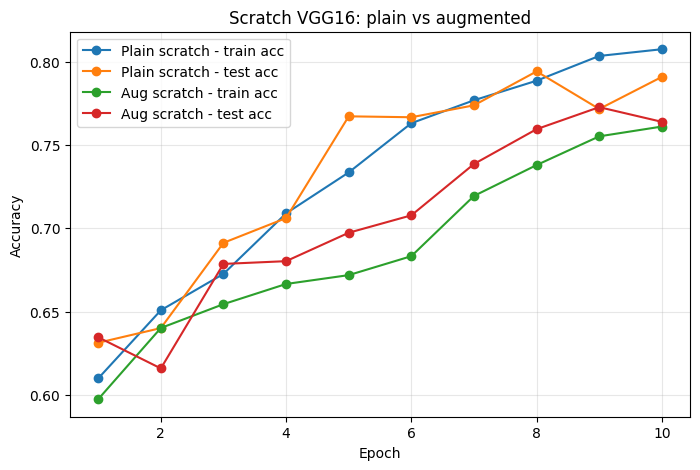

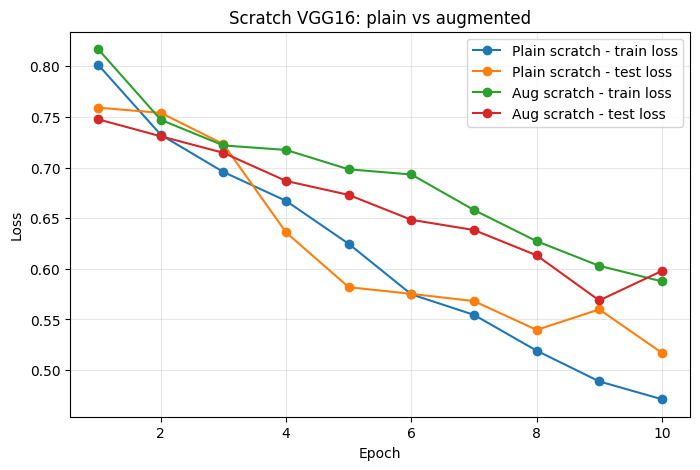

CPU times: user 16min 2s, sys: 17.1 s, total: 16min 19s
Wall time: 18min 28s


In [ ]:
%%time

import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torchvision import transforms

# Reproducibility
torch.manual_seed(42)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(42)

# Augmentation for scratch model
train_aug_scratch_tfms = transforms.Compose([
    transforms.RandomResizedCrop(224, scale=(0.75, 1.0)),       # random crop
    transforms.RandomRotation(degrees=20),                      # random rotate
    transforms.RandomAffine(degrees=0, translate=(0.15, 0.15)), # random translate
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])

train_aug_scratch_ds = HFDatasetWrapper(train_ds, transform=train_aug_scratch_tfms)
train_aug_scratch_loader = DataLoader(
    train_aug_scratch_ds,
    batch_size=16,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

# Augmented scratch model
aug_scratch_model = VGG16(weights=None)
aug_scratch_model.classifier[6] = nn.Linear(
    aug_scratch_model.classifier[6].in_features,
    num_classes
)
aug_scratch_model = aug_scratch_model.to(device)

aug_scratch_hist = train_and_track(
    model=aug_scratch_model,
    train_loader=train_aug_scratch_loader,
    test_loader=test_loader,
    loss_fn=criterion,
    device=device,
    epochs=10,
    lr=1e-4,
)

# Compare with plain scratch baseline
scratch_aug_comparison = plain_hist.merge(
    aug_scratch_hist,
    on="epoch",
    suffixes=("_plain", "_aug")
)

scratch_aug_comparison["delta_test_acc_aug_minus_plain"] = (
    scratch_aug_comparison["test_acc_aug"] - scratch_aug_comparison["test_acc_plain"]
)
scratch_aug_comparison["delta_test_loss_aug_minus_plain"] = (
    scratch_aug_comparison["test_loss_aug"] - scratch_aug_comparison["test_loss_plain"]
)

display(scratch_aug_comparison.round(4))

plain_final = plain_hist.iloc[-1]["test_acc"]
aug_final = aug_scratch_hist.iloc[-1]["test_acc"]
plain_best = plain_hist["test_acc"].max()
aug_best = aug_scratch_hist["test_acc"].max()

print(f"Final test acc (plain scratch): {plain_final:.4f}")
print(f"Final test acc (aug scratch):   {aug_final:.4f}")
print(f"Best  test acc (plain scratch): {plain_best:.4f}")
print(f"Best  test acc (aug scratch):   {aug_best:.4f}")

if aug_best > plain_best:
    print("Discussion: augmentation improved generalization for scratch training.")
elif aug_best < plain_best:
    print("Discussion: augmentation appears too strong or dataset too small; scratch performance dropped.")
else:
    print("Discussion: augmentation had limited impact on peak scratch test accuracy.")

# ---- Plots: scratch plain vs augmented ----

plt.figure(figsize=(8, 5))
plt.plot(plain_hist["epoch"], plain_hist["train_acc"], marker="o", label="Plain scratch - train acc")
plt.plot(plain_hist["epoch"], plain_hist["test_acc"], marker="o", label="Plain scratch - test acc")
plt.plot(aug_scratch_hist["epoch"], aug_scratch_hist["train_acc"], marker="o", label="Aug scratch - train acc")
plt.plot(aug_scratch_hist["epoch"], aug_scratch_hist["test_acc"], marker="o", label="Aug scratch - test acc")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Scratch VGG16: plain vs augmented")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(plain_hist["epoch"], plain_hist["train_loss"], marker="o", label="Plain scratch - train loss")
plt.plot(plain_hist["epoch"], plain_hist["test_loss"], marker="o", label="Plain scratch - test loss")
plt.plot(aug_scratch_hist["epoch"], aug_scratch_hist["train_loss"], marker="o", label="Aug scratch - train loss")
plt.plot(aug_scratch_hist["epoch"], aug_scratch_hist["test_loss"], marker="o", label="Aug scratch - test loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Scratch VGG16: plain vs augmented")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

If we train it longer, we can get better result with data augmentation.
Following is the result for 50 epochs:
```
Final test acc (plain scratch): 0.5938
Final test acc (aug scratch):   0.7344
Best  test acc (plain scratch): 0.7188
Best  test acc (aug scratch):   0.7656
Discussion: augmentation improved generalization for scratch training.
CPU times: user 54.9 s, sys: 5.32 s, total: 1min
Wall time: 1min 7s
```

### Train the pre-trained VGG with data augmentation

In [ ]:
%%time

import matplotlib.pyplot as plt

# Stronger augmentation: random rotate + random translate + random crop
train_aug_tfms = transforms.Compose([
    transforms.RandomResizedCrop(224, scale=(0.75, 1.0)),       # random crop
    transforms.RandomRotation(degrees=20),                      # random rotate
    transforms.RandomAffine(degrees=0, translate=(0.15, 0.15)), # random translate
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

train_aug_torch_ds = HFDatasetWrapper(train_ds, transform=train_aug_tfms)
train_aug_loader = DataLoader(
    train_aug_torch_ds,
    batch_size=16,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

# Train again (pretrained backbone, same setup as previous experiment)
aug_model = models.vgg16(weights=models.VGG16_Weights.IMAGENET1K_V1)
aug_model.classifier[6] = nn.Linear(aug_model.classifier[6].in_features, num_classes)
aug_model = aug_model.to(device)

aug_hist = train_and_track(
    model=aug_model,
    train_loader=train_aug_loader,
    test_loader=test_loader,
    loss_fn=criterion,
    device=device,
    epochs=10,
    lr=1e-5,
)

# Compare against previous pretrained run (pre_hist)
aug_comparison = pre_hist.merge(aug_hist, on="epoch", suffixes=("_base", "_aug"))
aug_comparison["delta_test_acc_aug_minus_base"] = (
    aug_comparison["test_acc_aug"] - aug_comparison["test_acc_base"]
)
aug_comparison["delta_test_loss_aug_minus_base"] = (
    aug_comparison["test_loss_aug"] - aug_comparison["test_loss_base"]
)

display(aug_comparison.round(4))

base_final = pre_hist.iloc[-1]["test_acc"]
aug_final = aug_hist.iloc[-1]["test_acc"]
base_best = pre_hist["test_acc"].max()
aug_best = aug_hist["test_acc"].max()

print(f"Final test acc (baseline pretrained):  {base_final:.4f}")
print(f"Final test acc (augmented pretrained): {aug_final:.4f}")
print(f"Best  test acc (baseline pretrained):  {base_best:.4f}")
print(f"Best  test acc (augmented pretrained): {aug_best:.4f}")

if aug_best > base_best:
    print("Discussion: augmentation improved generalization (higher best test accuracy).")
elif aug_best < base_best:
    print("Discussion: augmentation was too strong for this small dataset; test accuracy dropped.")
else:
    print("Discussion: augmentation had little effect on peak test accuracy.")

# ---- Plots: pretrained baseline vs augmented ----

plt.figure(figsize=(8, 5))
plt.plot(pre_hist["epoch"], pre_hist["train_acc"], marker="o", label="Baseline pretrained - train acc")
plt.plot(pre_hist["epoch"], pre_hist["test_acc"], marker="o", label="Baseline pretrained - test acc")
plt.plot(aug_hist["epoch"], aug_hist["train_acc"], marker="o", label="Augmented pretrained - train acc")
plt.plot(aug_hist["epoch"], aug_hist["test_acc"], marker="o", label="Augmented pretrained - test acc")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Pretrained VGG16: baseline vs augmented")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(pre_hist["epoch"], pre_hist["train_loss"], marker="o", label="Baseline pretrained - train loss")
plt.plot(pre_hist["epoch"], pre_hist["test_loss"], marker="o", label="Baseline pretrained - test loss")
plt.plot(aug_hist["epoch"], aug_hist["train_loss"], marker="o", label="Augmented pretrained - train loss")
plt.plot(aug_hist["epoch"], aug_hist["test_loss"], marker="o", label="Augmented pretrained - test loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Pretrained VGG16: baseline vs augmented")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

Downloading: "https://download.pytorch.org/models/vgg16-397923af.pth" to /root/.cache/torch/hub/checkpoints/vgg16-397923af.pth


100%|██████████| 528M/528M [00:07<00:00, 70.0MB/s]
/usr/local/lib/python3.12/dist-packages/torch/autograd/graph.py:865: UserWarning: adaptive_avg_pool2d_backward_cuda does not have a deterministic implementation, but you set 'torch.use_deterministic_algorithms(True, warn_only=True)'. You can file an issue at https://github.com/pytorch/pytorch/issues to help us prioritize adding deterministic support for this operation. (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:160.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


NameError: name 'pre_hist' is not defined

## Rebuild VGG19

Experiment with architecture: Rebuild VGG19. After layer block4_conv4 (32, 32, 512):

In [ ]:
import torch
import torch.nn as nn
from torchvision import models


class VGG19_Block4Conv4_Head(nn.Module):
    def __init__(self, num_classes, pretrained=True, freeze_conv3_and_before=True):
        super().__init__()

        weights = models.VGG19_Weights.IMAGENET1K_V1 if pretrained else None
        base = models.vgg19(weights=weights)

        # Up to block4_conv4 (+ ReLU)
        # block4_conv4 is index 25, relu is 26 → use [:27]
        self.features = nn.Sequential(*list(base.features.children())[:27])

        # Freeze conv3 and before (block1, block2, block3)
        if freeze_conv3_and_before:
            for layer in list(self.features.children())[:19]:
                for param in layer.parameters():
                    param.requires_grad = False

        # Bottleneck
        self.bottleneck = nn.Sequential(
            nn.Conv2d(512, 1024, kernel_size=1, stride=1, padding=0),
            nn.LeakyReLU(inplace=True),

            nn.Conv2d(1024, 1024, kernel_size=3, stride=1, padding=1),
            nn.ReLU(inplace=True),
        )

        # Prediction head
        self.classifier = nn.Sequential(
            nn.AdaptiveAvgPool2d((1, 1)),
            nn.Flatten(),

            nn.Linear(1024, 256),
            nn.ReLU(inplace=True),
            nn.Dropout(0.5),

            nn.Linear(256, num_classes),
        )

    def forward(self, x):
        x = self.features(x)    # (N, 512, ~28, ~28)
        x = self.bottleneck(x)  # (N, 1024, ~28, ~28)
        x = self.classifier(x)
        return x

In [ ]:
%%time

import matplotlib.pyplot as plt

vgg19_b4_model = VGG19_Block4Conv4_Head(
    num_classes=num_classes,
    pretrained=True
).to(device)

vgg19_b4_hist = train_and_track(
    model=vgg19_b4_model,
    train_loader=train_loader,
    test_loader=test_loader,
    loss_fn=criterion,
    device=device,
    epochs=10,
    lr=1e-5,
)

print(f"VGG19 (block4_conv4 + bottleneck) final test acc: {vgg19_b4_hist.iloc[-1]['test_acc']:.4f}")
print(f"VGG16 pretrained final test acc:                 {pre_hist.iloc[-1]['test_acc']:.4f}")

vgg_compare = pre_hist[["epoch", "train_acc", "test_acc", "train_loss", "test_loss"]].merge(
    vgg19_b4_hist[["epoch", "train_acc", "test_acc", "train_loss", "test_loss"]],
    on="epoch",
    suffixes=("_vgg16_pre", "_vgg19_b4"),
)

display(vgg_compare.round(4))

vgg16_final = pre_hist.iloc[-1]["test_acc"]
vgg19_final = vgg19_b4_hist.iloc[-1]["test_acc"]
vgg16_best = pre_hist["test_acc"].max()
vgg19_best = vgg19_b4_hist["test_acc"].max()

print(f"Final test acc (VGG16 pretrained): {vgg16_final:.4f}")
print(f"Final test acc (VGG19 bottleneck): {vgg19_final:.4f}")
print(f"Best  test acc (VGG16 pretrained): {vgg16_best:.4f}")
print(f"Best  test acc (VGG19 bottleneck): {vgg19_best:.4f}")

if vgg19_best > vgg16_best:
    print("Discussion: the modified VGG19 achieved better peak test accuracy than pretrained VGG16.")
elif vgg19_best < vgg16_best:
    print("Discussion: pretrained VGG16 performed better; the modified VGG19 may be harder to optimize on this dataset.")
else:
    print("Discussion: both models achieved the same peak test accuracy.")

# ---- Plots: VGG16 pretrained vs VGG19 bottleneck ----

plt.figure(figsize=(8, 5))
plt.plot(pre_hist["epoch"], pre_hist["train_acc"], marker="o", label="VGG16 pretrained - train acc")
plt.plot(pre_hist["epoch"], pre_hist["test_acc"], marker="o", label="VGG16 pretrained - test acc")
plt.plot(vgg19_b4_hist["epoch"], vgg19_b4_hist["train_acc"], marker="o", label="VGG19 bottleneck - train acc")
plt.plot(vgg19_b4_hist["epoch"], vgg19_b4_hist["test_acc"], marker="o", label="VGG19 bottleneck - test acc")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("VGG16 pretrained vs VGG19 bottleneck")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(pre_hist["epoch"], pre_hist["train_loss"], marker="o", label="VGG16 pretrained - train loss")
plt.plot(pre_hist["epoch"], pre_hist["test_loss"], marker="o", label="VGG16 pretrained - test loss")
plt.plot(vgg19_b4_hist["epoch"], vgg19_b4_hist["train_loss"], marker="o", label="VGG19 bottleneck - train loss")
plt.plot(vgg19_b4_hist["epoch"], vgg19_b4_hist["test_loss"], marker="o", label="VGG19 bottleneck - test loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("VGG16 pretrained vs VGG19 bottleneck")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

Downloading: "https://download.pytorch.org/models/vgg19-dcbb9e9d.pth" to /root/.cache/torch/hub/checkpoints/vgg19-dcbb9e9d.pth


100%|██████████| 548M/548M [00:06<00:00, 83.0MB/s]


VGG19 (block4_conv4 + bottleneck) final test acc: 0.9367


NameError: name 'pre_hist' is not defined

## Select final model

In [ ]:
# Select the trained pretrained VGG16 model as the final model for analysis
final_model = pretrained_model  # use your already-trained pretrained VGG16 baseline
final_hist = pre_hist           # history from the pretrained baseline run

print("Using pretrained VGG16 baseline for final evaluation.")
print(final_hist.tail(3))

NameError: name 'pretrained_model' is not defined

## Infrastructure used for training

In [ ]:
import platform
import torch

print("Infrastructure used")
print("-------------------")
print(f"Device used by PyTorch: {device}")
print(f"Python version: {platform.python_version()}")
print(f"PyTorch version: {torch.__version__}")

if torch.cuda.is_available():
    print(f"CUDA available: Yes")
    print(f"GPU name: {torch.cuda.get_device_name(0)}")
    props = torch.cuda.get_device_properties(0)
    print(f"GPU memory: {props.total_memory / (1024**3):.2f} GB")
else:
    print("CUDA available: No")
    print(f"CPU: {platform.processor()}")

## Inference time

In [ ]:
import time
import numpy as np

final_model.eval()

# Warm-up (important for GPU timing)
with torch.no_grad():
    for images, _ in test_loader:
        images = images.to(device)
        _ = final_model(images)
        break

times = []
total_images = 0

with torch.no_grad():
    for images, _ in test_loader:
        images = images.to(device)

        if torch.cuda.is_available():
            torch.cuda.synchronize()
        start = time.perf_counter()

        outputs = final_model(images)

        if torch.cuda.is_available():
            torch.cuda.synchronize()
        end = time.perf_counter()

        batch_time = end - start
        times.append(batch_time)
        total_images += images.size(0)

total_time = sum(times)
avg_time_per_batch = np.mean(times)
avg_time_per_image = total_time / total_images

print(f"Total inference time on test set: {total_time:.6f} s")
print(f"Average inference time per batch: {avg_time_per_batch:.6f} s")
print(f"Average inference time per image: {avg_time_per_image:.6f} s")
print(f"Average images per second: {1.0 / avg_time_per_image:.2f}")

## Number of parameters

In [ ]:
total_params = sum(p.numel() for p in final_model.parameters())
trainable_params = sum(p.numel() for p in final_model.parameters() if p.requires_grad)

print(f"Total parameters:     {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")

## Confusion matrix

In [ ]:
import numpy as np

final_model.eval()

y_true = []
y_pred = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = final_model(images)
        preds = outputs.argmax(dim=1)

        y_true.extend(labels.cpu().numpy())
        y_pred.extend(preds.cpu().numpy())

y_true = np.array(y_true)
y_pred = np.array(y_pred)

print(f"Collected {len(y_true)} test predictions.")


from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_true, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
fig, ax = plt.subplots(figsize=(6, 6))
disp.plot(ax=ax, cmap="Blues", colorbar=False)
plt.title("Confusion Matrix - Pretrained VGG16")
plt.show()

print("Raw confusion matrix:")
print(cm)


cm_no_diag = cm.copy()
np.fill_diagonal(cm_no_diag, 0)

max_confusion = cm_no_diag.max()

if max_confusion == 0:
    print("No class confusions found on the test set.")
else:
    confused_pairs = np.argwhere(cm_no_diag == max_confusion)
    print(f"Highest confusion count: {max_confusion}")
    print("Most confused class pairs:")
    for i, j in confused_pairs:
        print(f"- True: {class_names[i]} -> Predicted: {class_names[j]}")

In [ ]:
from datasets import load_dataset

custom_ds = load_dataset("imagefolder", data_dir="custom_test")
custom_test_ds = custom_ds["train"]

print(custom_test_ds)

In [ ]:
# wrap
custom_torch_ds = HFDatasetWrapper(custom_test_ds, transform=test_tfms)

custom_loader = DataLoader(
    custom_torch_ds,
    batch_size=16,
    shuffle=False
)

In [ ]:
# run predictions
import numpy as np

final_model.eval()

y_true = []
y_pred = []

with torch.no_grad():
    for images, labels in custom_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = final_model(images)
        preds = outputs.argmax(dim=1)

        y_true.extend(labels.cpu().numpy())
        y_pred.extend(preds.cpu().numpy())

y_true = np.array(y_true)
y_pred = np.array(y_pred)

In [ ]:
# Accuracy
acc = (y_true == y_pred).mean()
print(f"Custom test accuracy: {acc:.4f} ({100*acc:.2f}%)")

In [ ]:
# Confusion matrix
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_true, y_pred)

disp = ConfusionMatrixDisplay(cm, display_labels=class_names)
disp.plot(cmap="Blues")
plt.title("Confusion Matrix - Custom Images")
plt.show()

In [ ]:
!pip install grad-cam

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import torch
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image

final_model.eval()

# Use last conv layer of VGG16
target_layers = [final_model.features[-1]]
cam = GradCAM(model=final_model, target_layers=target_layers)

# Denormalize image for visualization
def denormalize_image(img_tensor):
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
    std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
    img = img_tensor.cpu() * std + mean
    return img.clamp(0, 1)

# Predict + Grad-CAM
def predict_with_cam(idx):
    img_tensor, true_label = custom_torch_ds[idx]
    input_tensor = img_tensor.unsqueeze(0).to(device)

    with torch.no_grad():
        logits = final_model(input_tensor)
        probs = torch.softmax(logits, dim=1)[0]

        pred_label = probs.argmax().item()
        confidence = probs[pred_label].item()

    # Grad-CAM
    grayscale_cam = cam(input_tensor=input_tensor)[0]

    rgb_img = denormalize_image(img_tensor).permute(1, 2, 0).numpy()
    cam_overlay = show_cam_on_image(rgb_img, grayscale_cam, use_rgb=True)

    return {
        "rgb_img": rgb_img,
        "cam_overlay": cam_overlay,
        "true_label": true_label,
        "pred_label": pred_label,
        "confidence": confidence,
        "probs": probs.cpu().numpy(),
        "is_correct": (true_label == pred_label),
    }

In [ ]:
# Group indices by true label
samples_by_true_label = {name: [] for name in class_names}

for idx in range(len(custom_test_ds)):
    true_label = custom_test_ds[idx]["label"]
    class_name = class_names[true_label]
    samples_by_true_label[class_name].append(idx)

# Display results
for true_class in class_names:
    idxs = samples_by_true_label[true_class]
    n = len(idxs)

    print(f"\n=== TRUE LABEL: {true_class} ({n} images) ===")

    fig, axes = plt.subplots(n, 2, figsize=(10, 4 * n))
    if n == 1:
        axes = np.array([axes])

    for row, idx in enumerate(idxs):
        result = predict_with_cam(idx)

        probs = result["probs"]

        # Build probability text
        prob_text = "\n".join([
            f"{class_names[i]}: {probs[i]*100:.1f}%"
            for i in range(len(class_names))
        ])

        status = "TRUE" if result["is_correct"] else "FALSE"
        pred_name = class_names[result["pred_label"]]
        conf = result["confidence"] * 100

        # Original image
        axes[row, 0].imshow(result["rgb_img"])
        axes[row, 0].set_title(
            f"True: {true_class}\n"
            f"Pred: {pred_name} ({conf:.1f}%)\n"
            f"{prob_text}\n"
            f"{status}"
        )
        axes[row, 0].axis("off")

        # Grad-CAM
        axes[row, 1].imshow(result["cam_overlay"])
        axes[row, 1].set_title("Grad-CAM")
        axes[row, 1].axis("off")

    plt.tight_layout()
    plt.show()